In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.inspection import DecisionBoundaryDisplay
import seaborn as sns


In [2]:
# Loading the dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Spliting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating *** linear SVM classifier ***
linear_svm = SVC(kernel='linear', C=1.0, random_state=42)
linear_svm.fit(X_train_scaled, y_train)

# Make initial predictions
y_pred = linear_svm.predict(X_test_scaled)


In [3]:
# Using cross-validation to tune the regularization parameter C
# Define a range of C values to test
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

# Use Stratified K-Fold cross-validation to handle class imbalance
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(SVC(kernel='linear', random_state=42), param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Fetch the best C parameter
best_C = grid_search.best_params_['C']
print(f"Optimal C parameter: {best_C}")

# Retrain the model with the optimal C
optimal_svm = SVC(kernel='linear', C=best_C, random_state=42, probability=True)
optimal_svm.fit(X_train_scaled, y_train)
y_pred_optimal = optimal_svm.predict(X_test_scaled)


Optimal C parameter: 0.01


Accuracy: 0.9591
Precision: 0.9464
Recall: 0.9907
F1-Score: 0.9680

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.91      0.94        64
           1       0.95      0.99      0.97       107

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



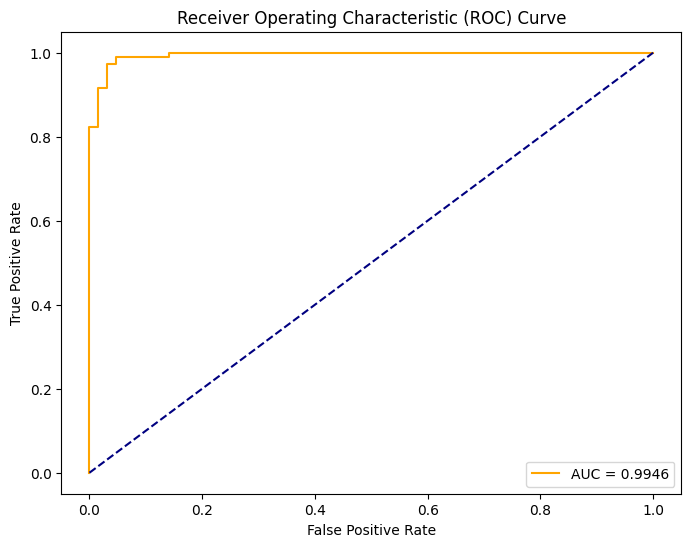

In [4]:
# To Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_optimal)
precision = precision_score(y_test, y_pred_optimal)
recall = recall_score(y_test, y_pred_optimal)
f1 = f1_score(y_test, y_pred_optimal)
report = classification_report(y_test, y_pred_optimal)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nClassification Report:\n", report)

# Plot ROC curve and calculate AUC
y_proba = optimal_svm.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


Performace by Class:

Class 0 (Malignant): Perscision is .98, so the model prodicted an instance was Class 0 correctly 98% of the time. Recall was 0.91, the model successfully identified 92% of actual Class 0 instances. The F-1 score was 0.94, which is a high level performance.

Class 1 (Benign): For percision, the model predicted an instance was in Class on correctly 95% of the time. The recall was 0.99 meaning it identified 99% of the actual instances in Class 1. The F-1 score was 0.97, which indiciates a very high performance for this class.

ROC Curve and AUC:

The AUC value is 0.9946 and is extremely close to the maximum value of 1.0. This score tells is that the model has an excellent ability to separate the positive and negative classes.

The graph shows how well the model can distinguish between malignant and benign tumors. Because the yellow line on the graph is positioned high and to the left, it indicates that the model is very effective. This means it is highly successful at correctly identifying malignant tumors (high true positive rate) while rarely mistaking benign tumors for malignant ones (low false positive rate).



<Figure size 1000x800 with 0 Axes>

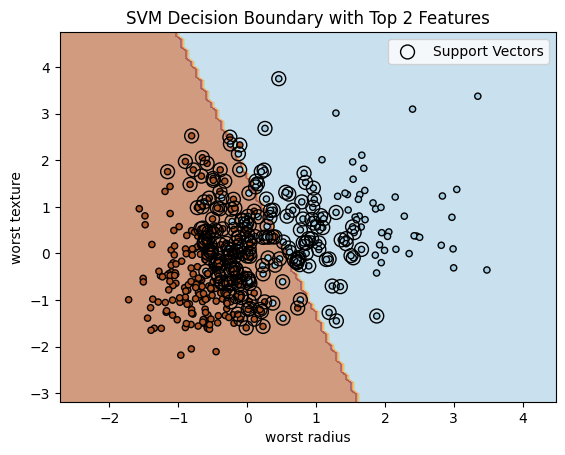

In [5]:
# Fetching the coefficients from the linear SVM to determine feature importance
coef = optimal_svm.coef_[0]
feature_names = cancer.feature_names
feature_importance = pd.DataFrame({'feature': feature_names, 'importance': np.abs(coef)})
feature_importance = feature_importance.sort_values('importance', ascending=False)

# Selecting the top 2 features
top_features = feature_importance.head(2)['feature'].values
top_feature_indices = [np.where(feature_names == f)[0][0] for f in top_features]

X_train_2d = X_train_scaled[:, top_feature_indices]
X_test_2d = X_test_scaled[:, top_feature_indices]

# Retrain an SVM on the two selected features
svm_2d = SVC(kernel='linear', C=best_C, random_state=42)
svm_2d.fit(X_train_2d, y_train)

# Plotting the decision boundary
plt.figure(figsize=(10, 8))
disp = DecisionBoundaryDisplay.from_estimator(
    svm_2d,
    X_train_2d,
    response_method="predict",
    cmap=plt.cm.Paired,
    alpha=0.6,
    xlabel=top_features[0],
    ylabel=top_features[1]
)
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap=plt.cm.Paired, edgecolors='k', s=20)
plt.scatter(svm_2d.support_vectors_[:, 0], svm_2d.support_vectors_[:, 1], s=100, facecolors='none', edgecolors='k', label='Support Vectors')
plt.title('SVM Decision Boundary with Top 2 Features')
plt.legend()
plt.show()


Here we see tjat Decosion boundary where the diagnoal line is seperating orange and blue resgions. Any new data point that is in orange region is malignant and any new data point that falls in to the blue region would be classiified as benign.

The most important data points( support vectors), are the ones that define where this dividing line is drawn. The visual confirms that the model has found an effective way to separate the two groups of tumors based on these two key features.



Number of misclassified samples: 7

Sample Index: 4
Actual Label: malignant (0)
Predicted Label: benign (1)
Feature values:
  mean radius: 14.4800
  mean texture: 21.4600
  mean perimeter: 94.2500
  mean area: 648.2000
  mean smoothness: 0.0944
  mean compactness: 0.0995
  mean concavity: 0.1204
  mean concave points: 0.0494
  mean symmetry: 0.2075
  mean fractal dimension: 0.0564
  radius error: 0.4204
  texture error: 2.2200
  perimeter error: 3.3010
  area error: 38.8700
  smoothness error: 0.0094
  compactness error: 0.0298
  concavity error: 0.0537
  concave points error: 0.0176
  symmetry error: 0.0242
  fractal dimension error: 0.0032
  worst radius: 16.2100
  worst texture: 29.2500
  worst perimeter: 108.4000
  worst area: 808.9000
  worst smoothness: 0.1306
  worst compactness: 0.1976
  worst concavity: 0.3349
  worst concave points: 0.1225
  worst symmetry: 0.3020
  worst fractal dimension: 0.0685

Sample Index: 13
Actual Label: malignant (0)
Predicted Label: benign (1)
Featu

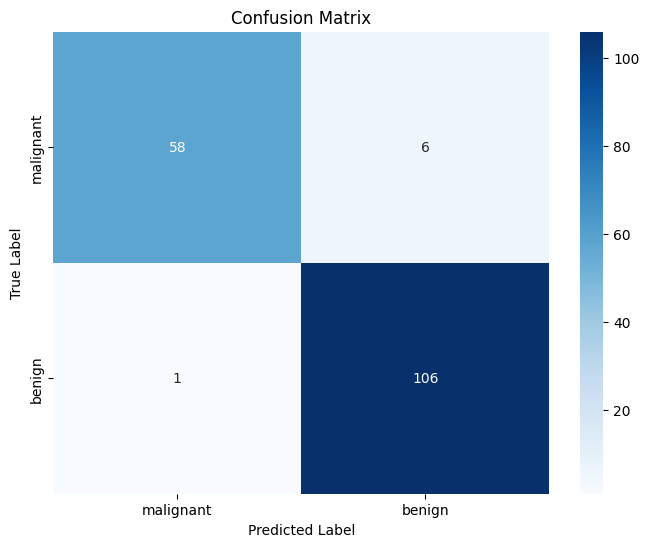

In [6]:
# Find indices of misclassified samples in the test set
misclassified_indices = np.where(y_pred_optimal != y_test)[0]

print(f"Number of misclassified samples: {len(misclassified_indices)}")

# Display details for each misclassified sample
for i in misclassified_indices:
    sample_data = X_test[i]
    true_label = y_test[i]
    predicted_label = y_pred_optimal[i]

    print(f"\nSample Index: {i}")
    print(f"Actual Label: {cancer.target_names[true_label]} ({true_label})")
    print(f"Predicted Label: {cancer.target_names[predicted_label]} ({predicted_label})")
    print("Feature values:")
    for feature_name, value in zip(feature_names, sample_data):
        print(f"  {feature_name}: {value:.4f}")

# Visualize misclassified instances using a confusion matrix
cm = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Based on the analysis of misclassified samples, you could further investigate
# potential reasons for misclassification, such as:
# *   Outliers
# *   Boundary cases (samples very close to the decision boundary)
# *   Features that might be more critical for correct classification


Correct Predictions:

58 Malignant Tumors:

The model correctly identified 58 malignant tumors. This is shown in the top-left cell, where the "True Label" was malignant and the "Predicted Label" was also malignant. Known as True Positives.

106 Benign Tumors:

The model correctly identified 106 benign tumors. This is shown in the bottom-right cell, where the "True Label" was benign and the "Predicted Label" was also benign. Known as True Negatives.

Incorrect Predictions (Misclassifications):

6 False Negatives:

The model incorrectly classified 6 malignant tumors as benign. This is shown in the top-right cell. This type of error is particularly critical as it means a malignant tumor was missed.

1 False Positive:

The model incorrectly classified 1 benign tumor as malignant. This is shown in the bottom-left cell. This error could lead to unnecessary
testing for a patient.


In summary, the model is very effective at classifying tumors, especially benign ones. However, the confusion matrix does highlight some areas for improvment that could cause very serious issue for patients.